$$\text{lag\_1}(t) = V_{t-1}$$

$$\text{ma\_10}(t) = \frac{1}{10}\sum_{i=1}^{10} V_{t-i}$$

$$\text{min\_sin}(t) = \sin\left(\frac{2\pi \cdot \text{tod}(t)}{390}\right), \quad \text{min\_cos}(t) = \cos\left(\frac{2\pi \cdot \text{tod}(t)}{390}\right)$$

$$\text{intra\_sin}(t) = \sin\left(\frac{2\pi \cdot (t \mod 5)}{5}\right), \quad \text{intra\_cos}(t) = \cos\left(\frac{2\pi \cdot (t \mod 5)}{5}\right)$$

$$\text{time\_of\_day}(t) = \text{tod}(t) = (\text{hour} \times 60 + \text{minute}) - 570$$

$$\text{day\_of\_week}(t) \in \{0, 1, 2, 3, 4\} \quad (0 = \text{Monday}, \ldots, 4 = \text{Friday})$$

$$\text{lag\_1\_5min}(t) = V_{t-5}$$

$$\text{hist\_bin\_avg}(t) = \frac{1}{5}\sum_{i=1}^{5} V_{\text{tod}(t),\, d-i}$$

$$\text{bar\_volatility}(t) = H_t - L_t$$

$$\text{gap\_from\_open}(t) = \frac{O_d - C_{d-1}}{C_{d-1}} \times 100$$

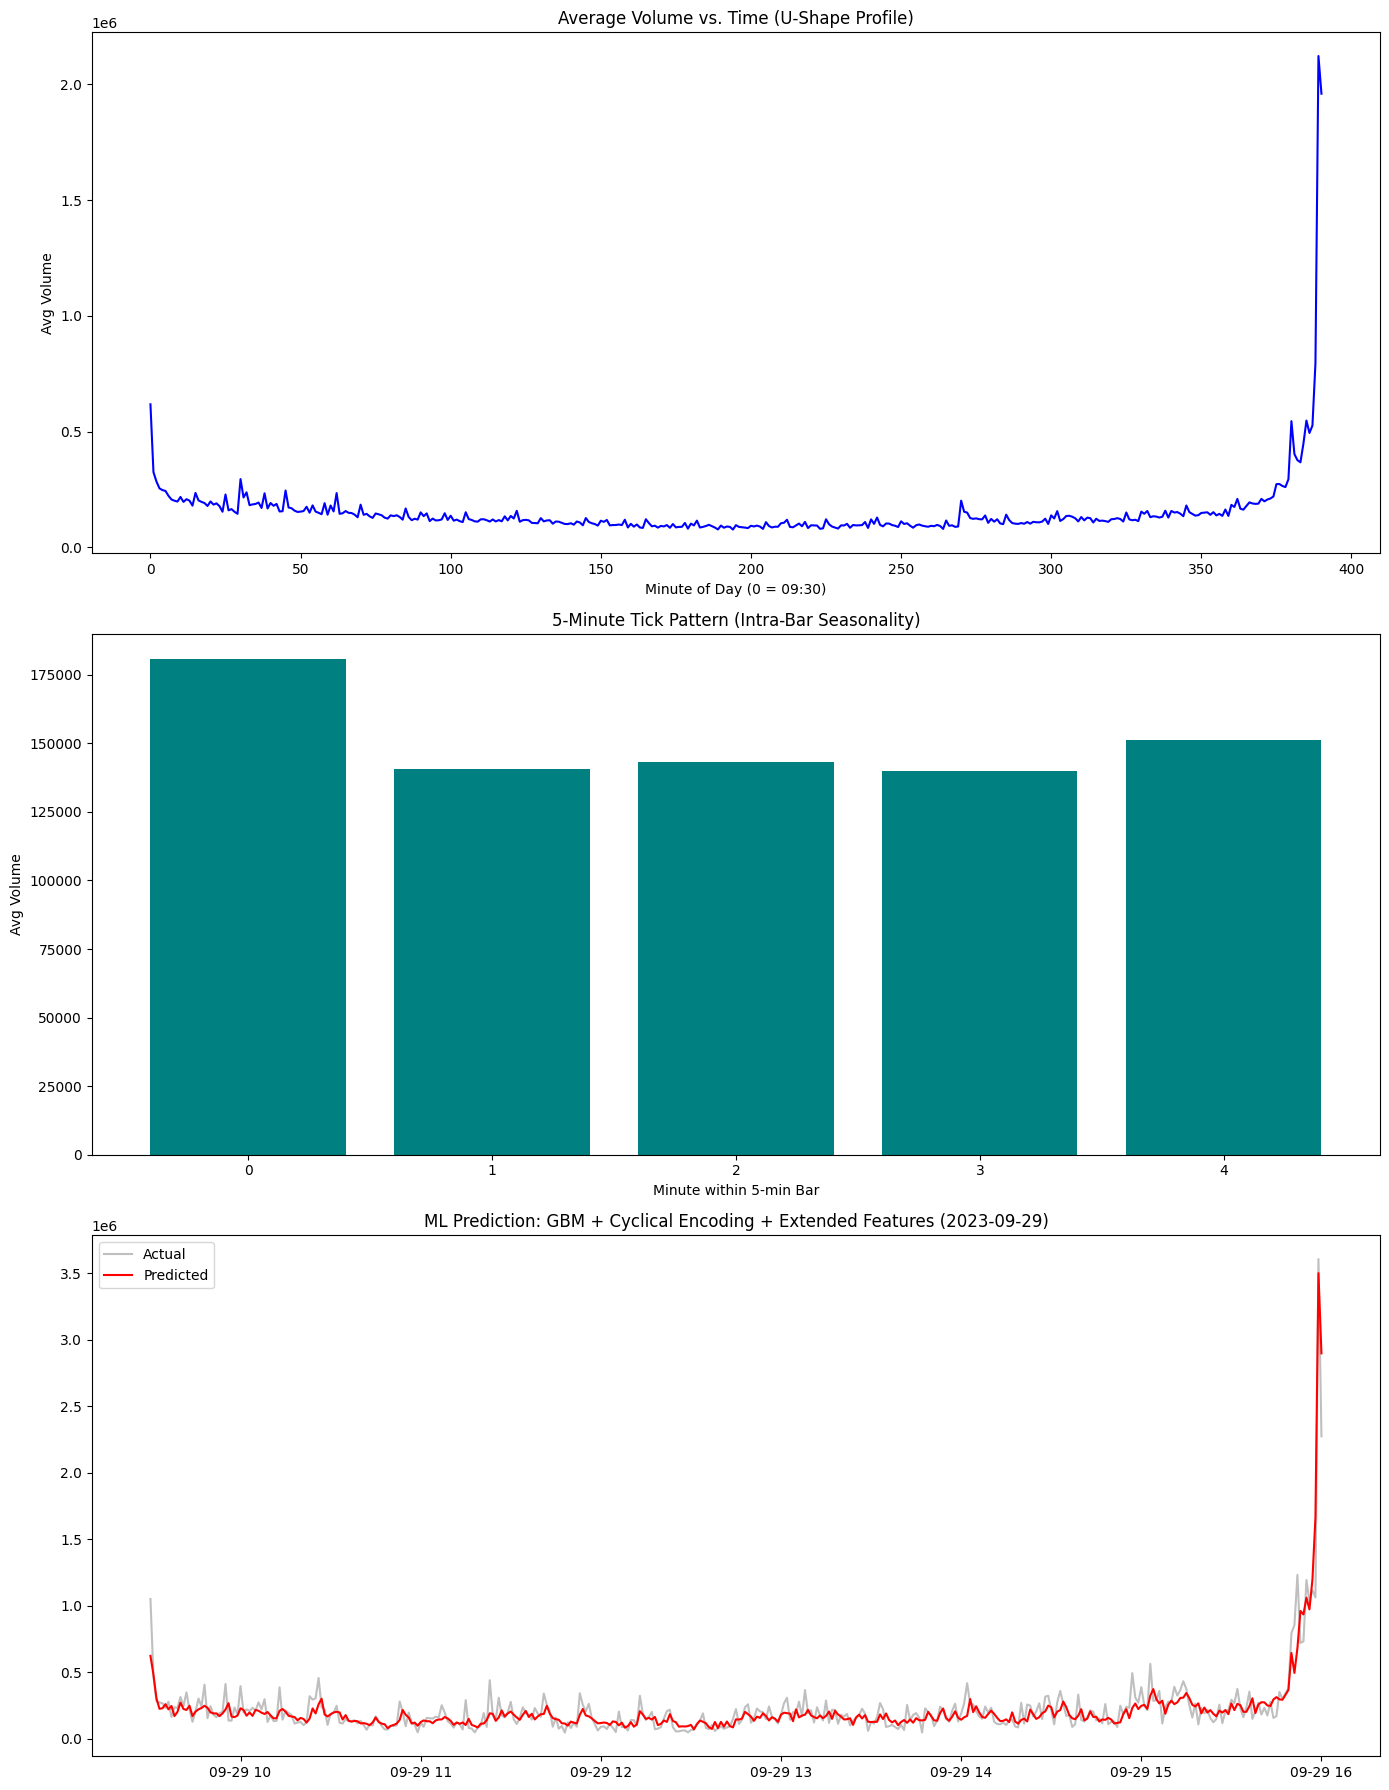


Feature list used:
  min_sin
  min_cos
  intra_sin
  intra_cos
  lag_1
  ma_10
  time_of_day
  day_of_week
  lag_1_5min
  hist_bin_avg
  bar_volatility
  gap_from_open


<Figure size 640x480 with 0 Axes>

In [3]:
# SPY Volume Prediction - GBM Model with Extended Features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Data Prep
# Add a feature `minite_of_day` that represents the number of minutes at which the current bar is from 9:30 market open
# Add a feature `intra_5min` that represents the position within a 5-minute window
df = pd.read_csv('SPY_1min_firstratedata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_rth = df.set_index('timestamp').between_time('09:30', '16:00').copy()
df_rth['minute_of_day'] = (df_rth.index.hour * 60 + df_rth.index.minute) - 570
df_rth['intra_5min'] = df_rth['minute_of_day'] % 5

# 2. Cyclical encoding: map time to (sin, cos) so the model sees t=0 (09:30) and t=389 (15:59) as nearly adjacent
# end of one day is close to the start of the next.
# min_sin/cos: position within the 390-min trading day
# intra_sin/cos: position within each 5-min bar (0–4)
df_rth['min_sin'] = np.sin(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['min_cos'] = np.cos(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['intra_sin'] = np.sin(2 * np.pi * df_rth['intra_5min'] / 5)
df_rth['intra_cos'] = np.cos(2 * np.pi * df_rth['intra_5min'] / 5)

# 3. Original Features: Lags & Moving Average
# lag_1: volume of the previous 1-min bar
# ma_10: average volume over the previous 10 bars (no look-ahead)
df_rth['lag_1'] = df_rth['volume'].shift(1)
df_rth['ma_10'] = df_rth['volume'].rolling(window=10).mean().shift(1)

# 4. New Features
# NEW FEATURE 1: `Time-of-Day`, identical to minute_of_day, raw minute position (0–389). 
# min_sin/cos already handle the cyclical U-shape. This gives the model a straight linear ramp
# so it can learn "early/late in day = more volume" directly.
df_rth['time_of_day'] = df_rth['minute_of_day']   # 0–389

# NEW FEATURE 2: Day-of-Week (0 = Monday, 4 = Friday)
df_rth['day_of_week'] = df_rth.index.dayofweek

# NEW FEATURE 3: Lag-1 Volume (volume of the previous 5-minute bar)
# We define a "5-minute bar" as the bar whose minute_of_day is t - 5
df_rth['lag_1_5min'] = df_rth['volume'].shift(5)

# NEW FEATURE 4: Historical Bin Average
# Average volume for this specific minute_of_day slot over the last 5 calendar days
# Shifting by 1 row, the rolling per-bin mean uses only past observations so there is no look-ahead bias.
# Sort the timestamp first in case that the csv file has non-time-increasing order rows.
# e.g. for the 09:30 bin on a Friday, hist_bin_avg is the mean of the 09:30 volumes
# from the previous 5 trading days (Thursday, Wednesday, Tuesday, Monday, last Friday)
df_rth = df_rth.sort_index()
df_rth['hist_bin_avg'] = (
    df_rth.groupby('minute_of_day')['volume']
          .transform(lambda x: x.shift(1)              # exclude current bar
                                .rolling(window=5,      # last 5 occurrences
                                         min_periods=1)
                                .mean())
)

# NEW FEATURE 5: Bar Volatility (High – Low of the current 1-min bar)
df_rth['bar_volatility'] = df_rth['high'] - df_rth['low']

# NEW FEATURE 6: Gap from Open
#   % difference between today's opening price and yesterday's close.
#   Both values are the same for every bar within the same day, so we
#   merge them in via a per-date lookup.

# Today's open = first 'open' price of each trading day
daily_open = (df_rth.groupby(df_rth.index.date)['open']
                    .first()
                    .rename('day_open'))
daily_open.index = pd.to_datetime(daily_open.index)

# Yesterday's close = last 'close' price of the prior trading day
daily_close = (df_rth.groupby(df_rth.index.date)['close']
                     .last()
                     .rename('prev_close'))
daily_close.index = pd.to_datetime(daily_close.index)
daily_close_shifted = daily_close.shift(1)          # shift to align with next day

gap_df = pd.DataFrame({'day_open': daily_open,
                       'prev_close': daily_close_shifted})
gap_df['gap_from_open'] = (gap_df['day_open'] - gap_df['prev_close']) / gap_df['prev_close'] * 100

# Map back to the 1-min dataframe using the date portion of the index
df_rth['gap_from_open'] = df_rth.index.normalize().map(gap_df['gap_from_open'])

# -------------------------------------------------------

df_ml = df_rth.dropna()

# 4. Train/Test Split & GBM Model — extended feature set
features = [
    # Original cyclical encoding
    'min_sin', 'min_cos',
    'intra_sin', 'intra_cos',
    # Original lags
    'lag_1', 'ma_10',
    # ---- NEW FEATURES ----
    'time_of_day',       # raw minute position (linear signal)
    'day_of_week',       # Mon–Fri seasonality
    'lag_1_5min',        # volume of the previous 5-minute bar
    'hist_bin_avg',      # historical average for this time slot (5-day)
    'bar_volatility',    # High – Low spread
    'gap_from_open',     # overnight gap %
]

X, y = df_ml[features], df_ml['volume']
split = int(len(df_ml) * 0.8)
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1
).fit(X[:split], y[:split])
y_pred = model.predict(X[split:])

# 5. Integrated Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Subplot 1: Avg Volume vs Time
avg_vol_tod = df_rth.groupby('minute_of_day')['volume'].mean()
axes[0].plot(avg_vol_tod.index, avg_vol_tod.values, color='blue')
axes[0].set_title('Average Volume vs. Time (U-Shape Profile)')
axes[0].set_xlabel('Minute of Day (0 = 09:30)')
axes[0].set_ylabel('Avg Volume')

# Subplot 2: 5-Min Tick Pattern
avg_vol_5min = df_rth.groupby('intra_5min')['volume'].mean()
axes[1].bar(avg_vol_5min.index, avg_vol_5min.values, color='teal')
axes[1].set_title('5-Minute Tick Pattern (Intra-Bar Seasonality)')
axes[1].set_xlabel('Minute within 5-min Bar')
axes[1].set_ylabel('Avg Volume')

# Subplot 3: ML Predictions (last trading day in test set)
sample_mask = df_ml.index[split:].date == df_ml.index[-1].date()
axes[2].plot(df_ml.index[split:][sample_mask],
             y[split:][sample_mask],
             color='gray', alpha=0.5, label='Actual')
axes[2].plot(df_ml.index[split:][sample_mask],
             y_pred[sample_mask],
             color='red', label='Predicted')
axes[2].set_title(
    f'ML Prediction: GBM + Cyclical Encoding + Extended Features '
    f'({df_ml.index[-1].date()})'
)
axes[2].legend()

plt.tight_layout()
plt.show()
plt.savefig("chart.png")

# Optional: quick feature importance summary
print("\nFeature list used:")
for f in features:
    print(f"  {f}")

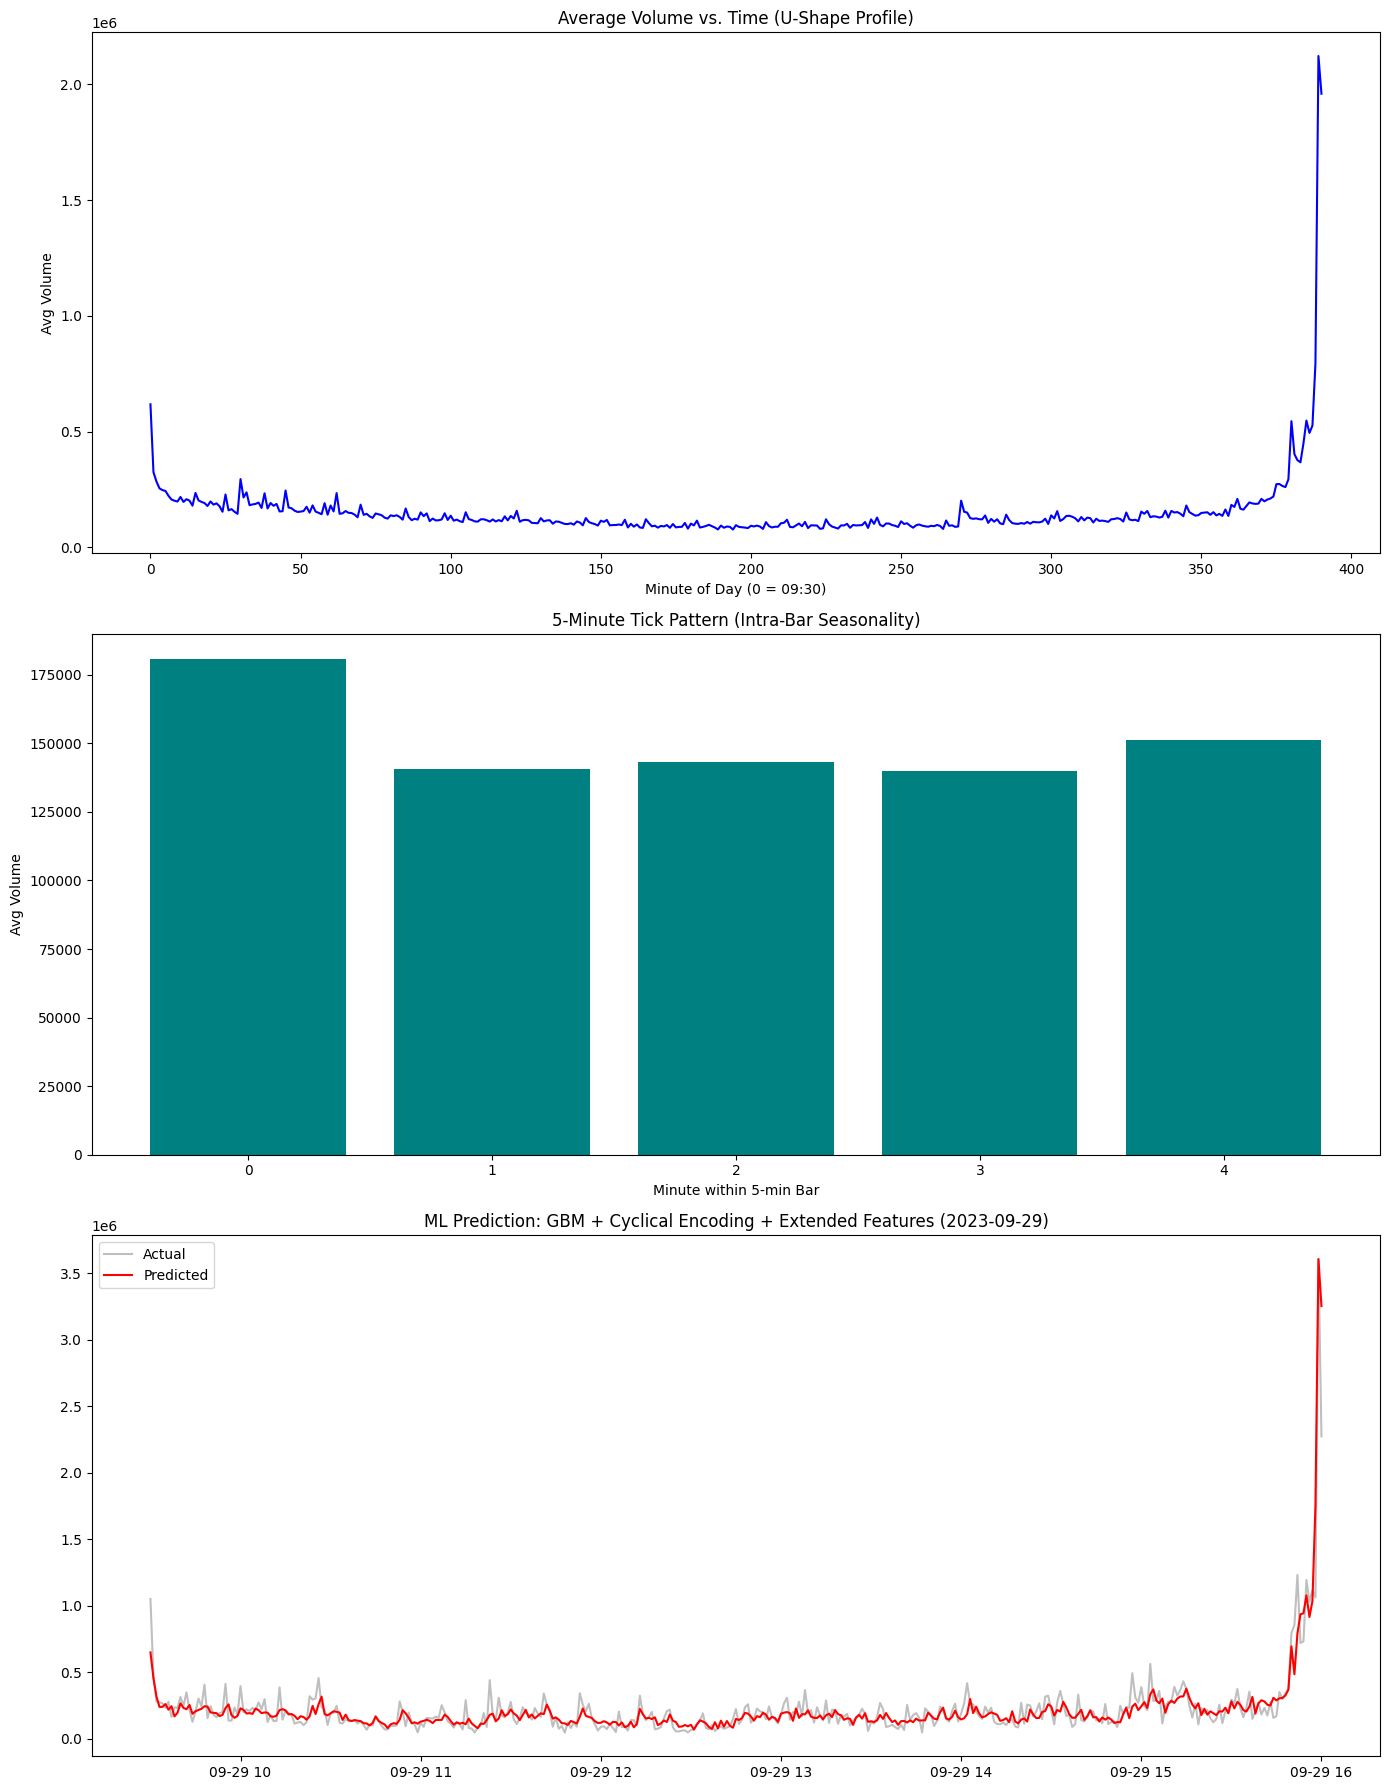


Feature list used:
  min_sin
  min_cos
  intra_sin
  intra_cos
  lag_1
  ma_10
  time_of_day
  day_of_week
  lag_1_5min
  hist_bin_avg
  bar_volatility
  gap_from_open


<Figure size 640x480 with 0 Axes>

In [4]:
# SPY Volume Prediction - GBM Model with Extended Features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Data Prep
# Add a feature `minite_of_day` that represents the number of minutes at which the current bar is from 9:30 market open
# Add a feature `intra_5min` that represents the position within a 5-minute window
df = pd.read_csv('SPY_1min_firstratedata.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_rth = df.set_index('timestamp').between_time('09:30', '16:00').copy()
df_rth['minute_of_day'] = (df_rth.index.hour * 60 + df_rth.index.minute) - 570
df_rth['intra_5min'] = df_rth['minute_of_day'] % 5

# 2. Cyclical encoding: map time to (sin, cos) so the model sees t=0 (09:30) and t=389 (15:59) as nearly adjacent
# end of one day is close to the start of the next.
# min_sin/cos: position within the 390-min trading day
# intra_sin/cos: position within each 5-min bar (0–4)
df_rth['min_sin'] = np.sin(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['min_cos'] = np.cos(2 * np.pi * df_rth['minute_of_day'] / 390)
df_rth['intra_sin'] = np.sin(2 * np.pi * df_rth['intra_5min'] / 5)
df_rth['intra_cos'] = np.cos(2 * np.pi * df_rth['intra_5min'] / 5)

# 3. Original Features: Lags & Moving Average
# lag_1: volume of the previous 1-min bar
# ma_10: average volume over the previous 10 bars (no look-ahead)
df_rth['lag_1'] = df_rth['volume'].shift(1)
df_rth['ma_10'] = df_rth['volume'].rolling(window=10).mean().shift(1)

# 4. New Features
# NEW FEATURE 1: `Time-of-Day`, identical to minute_of_day, raw minute position (0–389). 
# min_sin/cos already handle the cyclical U-shape. This gives the model a straight linear ramp
# so it can learn "early/late in day = more volume" directly.
df_rth['time_of_day'] = df_rth['minute_of_day']   # 0–389

# NEW FEATURE 2: Day-of-Week (0 = Monday, 4 = Friday)
df_rth['day_of_week'] = df_rth.index.dayofweek

# NEW FEATURE 3: Lag-1 Volume (volume of the previous 5-minute bar)
# We define a "5-minute bar" as the bar whose minute_of_day is t - 5
df_rth['lag_1_5min'] = df_rth['volume'].shift(5)

# NEW FEATURE 4: Historical Bin Average
# Average volume for this specific minute_of_day slot over the last 5 calendar days
# Shifting by 1 row, the rolling per-bin mean uses only past observations so there is no look-ahead bias.
# Sort the timestamp first in case that the csv file has non-time-increasing order rows.
# e.g. for the 09:30 bin on a Friday, hist_bin_avg is the mean of the 09:30 volumes
# from the previous 5 trading days (Thursday, Wednesday, Tuesday, Monday, last Friday)
df_rth = df_rth.sort_index()
df_rth['hist_bin_avg'] = (
    df_rth.groupby('minute_of_day')['volume']
          .transform(lambda x: x.shift(1)              # exclude current bar
                                .rolling(window=5,      # last 5 occurrences
                                         min_periods=1)
                                .mean())
)

# NEW FEATURE 5: Bar Volatility (High – Low of the current 1-min bar)
df_rth['bar_volatility'] = df_rth['high'] - df_rth['low']

# NEW FEATURE 6: Gap from Open
#   % difference between today's opening price and yesterday's close.
#   Both values are the same for every bar within the same day, so we
#   merge them in via a per-date lookup.

# Today's open = first 'open' price of each trading day
daily_open = (df_rth.groupby(df_rth.index.date)['open']
                    .first()
                    .rename('day_open'))
daily_open.index = pd.to_datetime(daily_open.index)

# Yesterday's close = last 'close' price of the prior trading day
daily_close = (df_rth.groupby(df_rth.index.date)['close']
                     .last()
                     .rename('prev_close'))
daily_close.index = pd.to_datetime(daily_close.index)
daily_close_shifted = daily_close.shift(1)          # shift to align with next day

gap_df = pd.DataFrame({'day_open': daily_open,
                       'prev_close': daily_close_shifted})
gap_df['gap_from_open'] = (gap_df['day_open'] - gap_df['prev_close']) / gap_df['prev_close'] * 100

# Map back to the 1-min dataframe using the date portion of the index
df_rth['gap_from_open'] = df_rth.index.normalize().map(gap_df['gap_from_open'])

# -------------------------------------------------------

df_ml = df_rth.dropna()

# 4. Train/Test Split & GBM Model — extended feature set
features = [
    # Original cyclical encoding
    'min_sin', 'min_cos',
    'intra_sin', 'intra_cos',
    # Original lags
    'lag_1', 'ma_10',
    # ---- NEW FEATURES ----
    'time_of_day',       # raw minute position (linear signal)
    'day_of_week',       # Mon–Fri seasonality
    'lag_1_5min',        # volume of the previous 5-minute bar
    'hist_bin_avg',      # historical average for this time slot (5-day)
    'bar_volatility',    # High – Low spread
    'gap_from_open',     # overnight gap %
]

X, y = df_ml[features], df_ml['volume']
split = int(len(df_ml) * 0.8)
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1
).fit(X[:split], y[:split])
y_pred = model.predict(X[split:])

# 5. Integrated Visualization
# fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig1, ax1 = plt.subplots(figsize=(14, 6))
fig2, ax2 = plt.subplots(figsize=(14, 6))
fig3, ax3 = plt.subplots(figsize=(14, 6))

# Subplot 1: Avg Volume vs Time
avg_vol_tod = df_rth.groupby('minute_of_day')['volume'].mean()
ax1.plot(avg_vol_tod.index, avg_vol_tod.values, color='blue')
ax1.set_title('Average Volume vs. Time (U-Shape Profile)')
ax1.set_xlabel('Minute of Day (0 = 09:30)')
ax1.set_ylabel('Avg Volume')

# Subplot 2: 5-Min Tick Pattern
avg_vol_5min = df_rth.groupby('intra_5min')['volume'].mean()
ax2.bar(avg_vol_5min.index, avg_vol_5min.values, color='teal')
ax2.set_title('5-Minute Tick Pattern (Intra-Bar Seasonality)')
ax2.set_xlabel('Minute within 5-min Bar')
ax2.set_ylabel('Avg Volume')

# Subplot 3: ML Predictions (last trading day in test set)
sample_mask = df_ml.index[split:].date == df_ml.index[-1].date()
axes[2].plot(df_ml.index[split:][sample_mask],
             y[split:][sample_mask],
             color='gray', alpha=0.5, label='Actual')
axes[2].plot(df_ml.index[split:][sample_mask],
             y_pred[sample_mask],
             color='red', label='Predicted')
axes[2].set_title(
    f'ML Prediction: GBM + Cyclical Encoding + Extended Features '
    f'({df_ml.index[-1].date()})'
)
axes[2].legend()

plt.tight_layout()
plt.show()
plt.savefig("chart.png")

# Optional: quick feature importance summary
print("\nFeature list used:")
for f in features:
    print(f"  {f}")